Importing

In [1]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator
)

from tensorflow.keras.applications import (
    MobileNetV2
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (

    Dense,

    Dropout,

    GlobalAveragePooling2D

)

from tensorflow.keras.callbacks import (

    EarlyStopping,

    ReduceLROnPlateau

)

import matplotlib.pyplot as plt

import os

Paths

In [2]:
train_path = "../dataset/train"

test_path = "../dataset/test"

Parameters

In [3]:
IMG_SIZE = 224

BATCH_SIZE = 32

EPOCHS = 15

Data Generators

In [4]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    width_shift_range=0.2,

    height_shift_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.2

)

test_datagen = ImageDataGenerator(

    rescale=1./255

)

Training

In [ ]:
train_generator = train_datagen.flow_from_directory(

    train_path,

    target_size=(IMG_SIZE,IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training'

)

Found 795 images belonging to 4 classes.


Validation

In [6]:
validation_generator = train_datagen.flow_from_directory(

    train_path,

    target_size=(IMG_SIZE,IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation'

)

Found 196 images belonging to 4 classes.


Testing

In [7]:
test_generator = test_datagen.flow_from_directory(

    test_path,

    target_size=(IMG_SIZE,IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    shuffle=False

)

Found 99 images belonging to 4 classes.


Loading base model

In [8]:
base_model = MobileNetV2(

    weights='imagenet',

    include_top=False,

    input_shape=(IMG_SIZE,IMG_SIZE,3)

)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Freeze Pretrained Layer

In [9]:
base_model.trainable = False

Model Building

In [10]:
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dropout(0.3),

    Dense(

        128,

        activation='relu'

    ),

    Dropout(0.3),

    Dense(

        4,

        activation='softmax'

    )

])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Compile mode

In [12]:
model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

Callbacks

In [13]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=3,

    min_lr=1e-6

)

Train model

In [14]:
history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=EPOCHS,

    callbacks=[

        early_stop,

        reduce_lr

    ]

)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.8239 - loss: 0.4207 - val_accuracy: 0.9439 - val_loss: 0.1415 - learning_rate: 0.0010
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9497 - loss: 0.1332 - val_accuracy: 0.9439 - val_loss: 0.1052 - learning_rate: 0.0010
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9660 - loss: 0.0817 - val_accuracy: 0.9643 - val_loss: 0.0993 - learning_rate: 0.0010
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9686 - loss: 0.0777 - val_accuracy: 0.9694 - val_loss: 0.0995 - learning_rate: 0.0010
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9711 - loss: 0.0736 - val_accuracy: 0.9592 - val_loss: 0.1107 - learning_rate: 0.0010
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9736 - loss: 0.0685 - val_accuracy: 0.9745 - val_loss: 0.0909 - learning_rate: 0.0010
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9761 - loss: 0.0647 - val_accuracy: 

Test Evaluation

In [15]:
test_loss, test_accuracy = model.evaluate(

    test_generator

)

print(

    "Test Accuracy:",

    test_accuracy

)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 555ms/step - accuracy: 0.9394 - loss: 0.1445
Test Accuracy: 0.939393937587738


Predictions

In [16]:
predictions = model.predict(

    test_generator

)

predicted_classes = predictions.argmax(

    axis=1

)

true_classes = test_generator.classes

4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step


In [17]:
predictions = model.predict(

    test_generator

)

predicted_classes = predictions.argmax(

    axis=1

)

true_classes = test_generator.classes

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 449ms/step


Classification Report

In [18]:
from sklearn.metrics import (

    classification_report,

    confusion_matrix

)

print(

    classification_report(

        true_classes,

        predicted_classes,

        target_names=list(

            test_generator.class_indices.keys()

        )

    )

)

              precision    recall  f1-score   support

   blackspot       0.87      0.91      0.89        22
      canker       0.86      0.86      0.86        22
       fresh       1.00      0.97      0.98        33
    grenning       1.00      1.00      1.00        22

    accuracy                           0.94        99
   macro avg       0.93      0.94      0.93        99
weighted avg       0.94      0.94      0.94        99



Confusion atrix

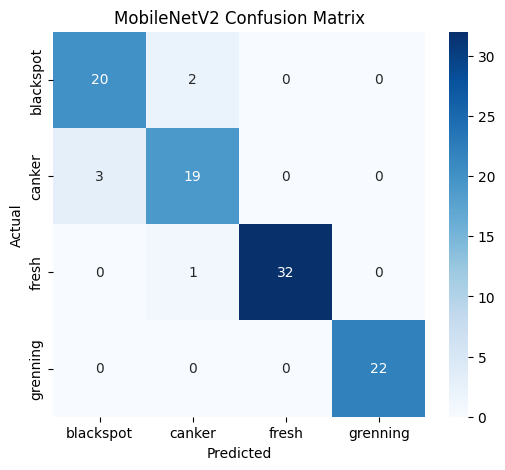

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(

    true_classes,

    predicted_classes

)

plt.figure(
    figsize=(6,5)
)

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=test_generator.class_indices.keys(),

    yticklabels=test_generator.class_indices.keys()

)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "MobileNetV2 Confusion Matrix"
)

plt.show()

In [20]:
model.save(
    "../model2/mobilenetv2_model.keras"
)